# Consolidado Final — versão com gráficos

## Objetivo
Este notebook foi reorganizado para funcionar como **apresentação executiva e didática** do dataset da Olist.

Em vez de apenas reunir análises soltas, ele procura responder a uma pergunta central:

> **O que mais limita a performance do e-commerce: demanda, logística, categoria, seller ou experiência do cliente?**

## Como ler este material
- Os gráficos abaixo foram **reconstruídos a partir dos notebooks-fonte** já analisados no projeto.
- O foco aqui é **comunicar o que importa para negócio**, sem exigir leitura técnica.
- Sempre que possível, usamos **medianas** e comparações simples, porque elas são mais estáveis e mais fáceis de explicar.


## Fontes principais utilizadas

- `notebooks/Gustavo/avaliacao_cliente.ipynb`
- `notebooks/Gustavo/vendedor_analise.ipynb`
- `notebooks/Davi/Analise_Estrategica_Ecommerce.ipynb`
- `notebooks/Davi/Analise_Sazonalidade.ipynb`
- `notebooks/Edvan/02_analise_regionalidade.ipynb`
- `notebooks/Edvan/03_analise_satisfacao.ipynb`
- `notebooks/Edvan/04_analise_categorias.ipynb`
- `notebooks/Edvan/05_analise_last_mile.ipynb`
- `notebooks/romulo/categoria_produto_executivo.ipynb`


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from PIL import Image

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25


Matplotlib is building the font cache; this may take a moment.


## 1. Visão geral do negócio

Antes de entrar nos detalhes, vale situar a operação.  
A base aponta para um marketplace grande, com bom volume, mas fortemente sensível à qualidade da execução logística.

O ponto-chave já aparece aqui: **prazo, frete e satisfação precisam ser lidos juntos**.


In [2]:
kpis = {
  "Receita total analisada (R$)": "15,7 mi",
  "Ticket médio por pedido (R$)": "160",
  "Avaliação média geral": "4,05",
  "Tempo médio de entrega (dias)": "12,0",
  "Pedidos com atraso": "7,8%",
  "Sellers em SP (top estado)": "1.849"
}
kpi_df = pd.DataFrame(list(kpis.items()), columns=['Indicador', 'Valor'])
kpi_df

,Indicador,Valor
0,Receita total analisada (R$),"15,7 mi"
1,Ticket médio por pedido (R$),160
2,Avaliação média geral,"4,05"
3,Tempo médio de entrega (dias),"12,0"
4,Pedidos com atraso,"7,8%"
5,Sellers em SP (top estado),1.849


## 2. O Brasil não compra sob as mesmas condições

**Base principal:** `notebooks/Edvan/02_analise_regionalidade.ipynb`

A operação é assimétrica desde o início:
- o **Sudeste concentra o volume**;
- os **sellers estão muito concentrados** em poucos polos;
- e regiões mais distantes pagam o preço disso em **frete e prazo**.

Em linguagem simples: **geografia vira custo e tempo de espera**.


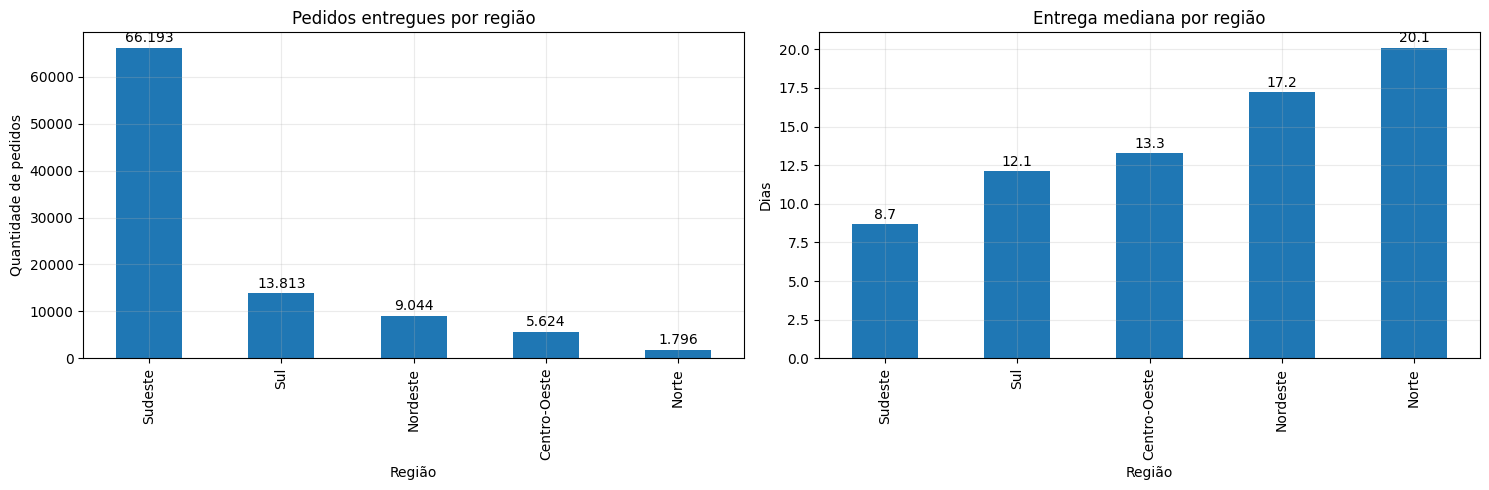

In [3]:
order_counts = {"Sudeste": 66193, "Sul": 13813, "Nordeste": 9044, "Centro-Oeste": 5624, "Norte": 1796}
median_delivery_region = {"Sudeste": 8.68, "Sul": 12.11, "Centro-Oeste": 13.27, "Nordeste": 17.24, "Norte": 20.1}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

oc = pd.Series(order_counts)
oc.plot(kind='bar', ax=axes[0])
axes[0].set_title('Pedidos entregues por região')
axes[0].set_xlabel('Região')
axes[0].set_ylabel('Quantidade de pedidos')
for i, v in enumerate(oc.values):
    axes[0].text(i, v + 1200, f"{v:,.0f}".replace(',', '.'), ha='center')

md = pd.Series(median_delivery_region)
md.plot(kind='bar', ax=axes[1])
axes[1].set_title('Entrega mediana por região')
axes[1].set_xlabel('Região')
axes[1].set_ylabel('Dias')
for i, v in enumerate(md.values):
    axes[1].text(i, v + 0.35, f"{v:.1f}", ha='center')

plt.tight_layout()
plt.show()


### Leitura executiva
O contraste é forte. O Sudeste concentra a maior parte dos pedidos, enquanto Norte e Nordeste convivem com prazos bem mais altos.  
Isso indica que **a discussão não é apenas “onde vender mais”, mas “como servir melhor cada região”**.


## 3. Logística ruim vira insatisfação do cliente

**Bases principais:**  
- `notebooks/Gustavo/avaliacao_cliente.ipynb`  
- `notebooks/Davi/Analise_Estrategica_Ecommerce.ipynb`  
- `notebooks/Edvan/03_analise_satisfacao.ipynb`

Esta é a mensagem mais importante de toda a apresentação:

> **quando a entrega falha, a experiência do cliente desaba**.


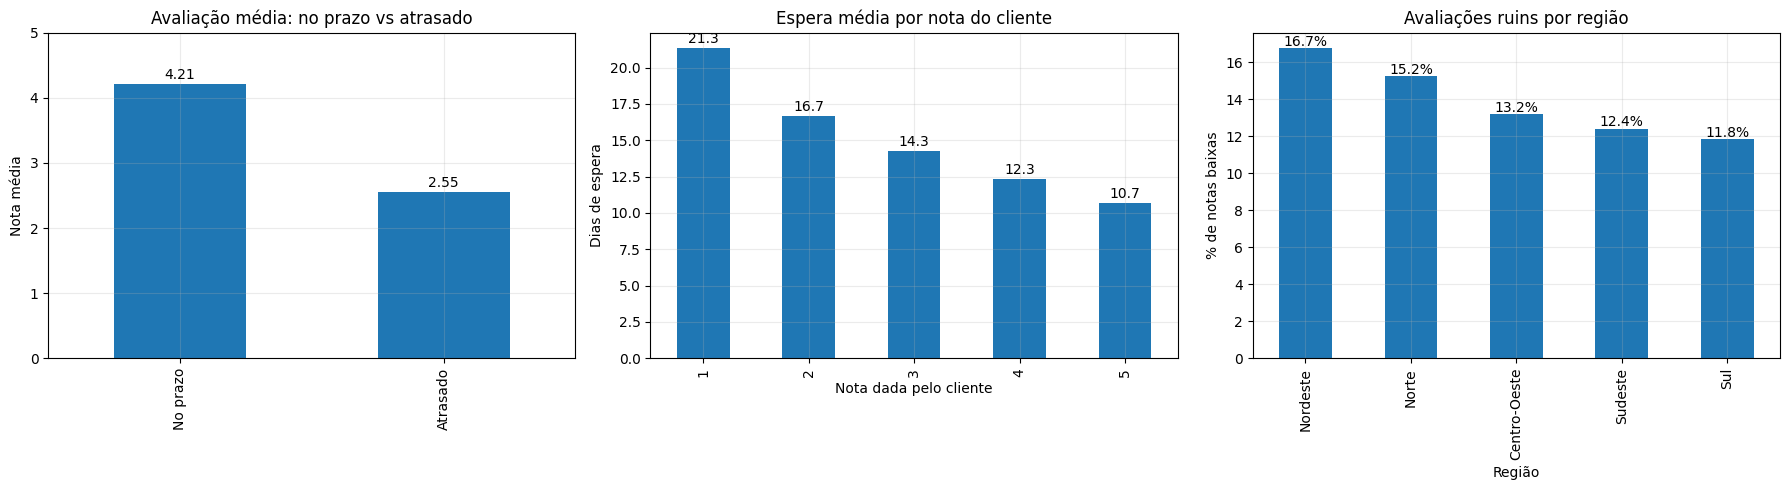

In [4]:
review_by_delivery_status = {"No prazo": 4.21, "Atrasado": 2.55}
avg_days_by_review = {"1": 21.32682487, "2": 16.66436334, "3": 14.25275642, "4": 12.30632, "5": 10.68107786}
low_rating_share = {"Nordeste": 16.74, "Norte": 15.23, "Centro-Oeste": 13.17, "Sudeste": 12.37, "Sul": 11.82}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

rds = pd.Series(review_by_delivery_status)
rds.plot(kind='bar', ax=axes[0])
axes[0].set_title('Avaliação média: no prazo vs atrasado')
axes[0].set_xlabel('')
axes[0].set_ylabel('Nota média')
axes[0].set_ylim(0, 5)
for i, v in enumerate(rds.values):
    axes[0].text(i, v + 0.08, f"{v:.2f}", ha='center')

adr = pd.Series(avg_days_by_review)
adr.plot(kind='bar', ax=axes[1])
axes[1].set_title('Espera média por nota do cliente')
axes[1].set_xlabel('Nota dada pelo cliente')
axes[1].set_ylabel('Dias de espera')
for i, v in enumerate(adr.values):
    axes[1].text(i, v + 0.35, f"{v:.1f}", ha='center')

lrs = pd.Series(low_rating_share)
lrs.plot(kind='bar', ax=axes[2])
axes[2].set_title('Avaliações ruins por região')
axes[2].set_xlabel('Região')
axes[2].set_ylabel('% de notas baixas')
for i, v in enumerate(lrs.values):
    axes[2].text(i, v + 0.15, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()


### Leitura executiva
Os três gráficos contam a mesma história por ângulos diferentes:
- pedidos **atrasados** derrubam a nota média;
- clientes que dão **nota 1** esperam muito mais;
- e regiões sob maior pressão logística acumulam **mais avaliações ruins**.

Para o negócio, isso muda tudo: logística não é apenas custo operacional.  
Ela afeta **reputação, confiança e chance de recompra**.


## 4. A última milha amplia o problema

**Base principal:** `notebooks/Edvan/05_analise_last_mile.ipynb`

Mesmo quando o pedido chega à região correta, o problema não acabou.  
A diferença entre **capital** e **interior** ajuda a explicar por que vender para certas áreas é mais caro e mais lento.


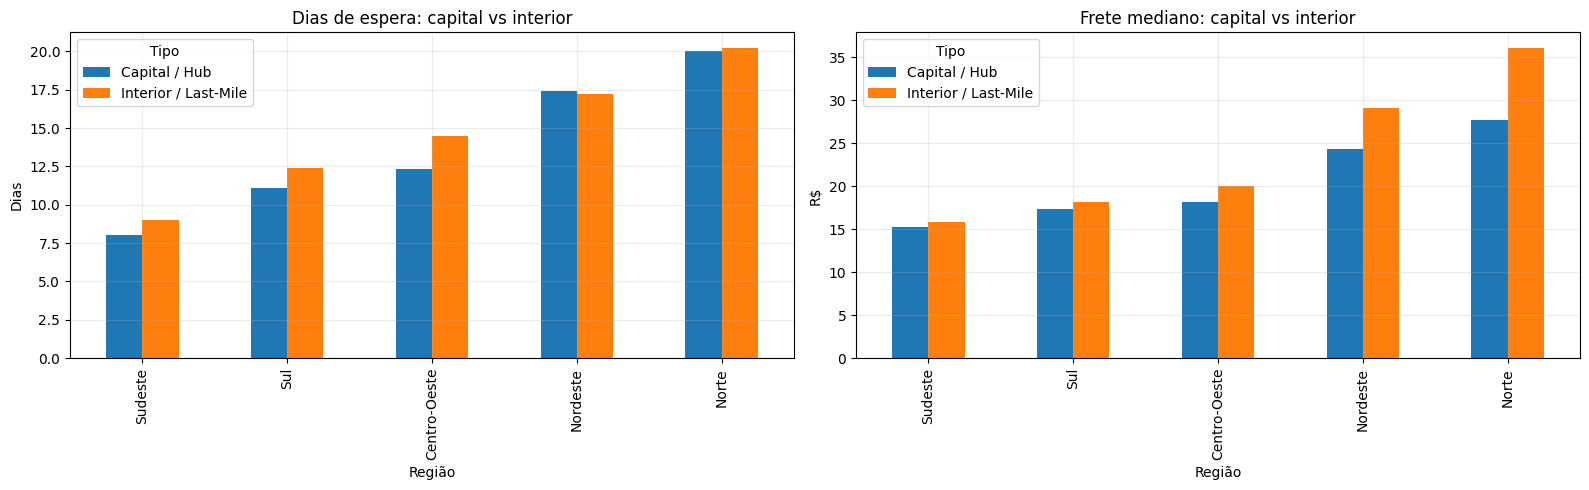

In [5]:
lastmile = pd.DataFrame([
    ['Centro-Oeste','Capital / Hub',12.306308,18.23],
    ['Centro-Oeste','Interior / Last-Mile',14.452743,20.09],
    ['Nordeste','Capital / Hub',17.437650,24.35],
    ['Nordeste','Interior / Last-Mile',17.232407,29.09],
    ['Norte','Capital / Hub',20.050382,27.66],
    ['Norte','Interior / Last-Mile',20.225185,36.11],
    ['Sudeste','Capital / Hub',8.054821,15.28],
    ['Sudeste','Interior / Last-Mile',9.014178,15.80],
    ['Sul','Capital / Hub',11.094936,17.37],
    ['Sul','Interior / Last-Mile',12.385521,18.23],
], columns=['Região','Tipo','Dias de Espera','Frete (R$)'])

ordem = ['Sudeste', 'Sul', 'Centro-Oeste', 'Nordeste', 'Norte']
pivot_days = lastmile.pivot(index='Região', columns='Tipo', values='Dias de Espera').loc[ordem]
pivot_freight = lastmile.pivot(index='Região', columns='Tipo', values='Frete (R$)').loc[ordem]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
pivot_days.plot(kind='bar', ax=axes[0])
axes[0].set_title('Dias de espera: capital vs interior')
axes[0].set_xlabel('Região')
axes[0].set_ylabel('Dias')

pivot_freight.plot(kind='bar', ax=axes[1])
axes[1].set_title('Frete mediano: capital vs interior')
axes[1].set_xlabel('Região')
axes[1].set_ylabel('R$')

plt.tight_layout()
plt.show()


### Leitura executiva
A diferença entre capital e interior não é detalhe operacional.  
Ela muda a viabilidade econômica da entrega.

O caso do Norte e do Nordeste é particularmente sensível:
- o frete do interior sobe bastante;
- e o tempo de espera continua alto.

Em termos práticos, **a última milha pode transformar uma venda boa em uma experiência ruim**.


## 5. Frete alto muda o comportamento de compra

**Bases principais:**  
- `notebooks/Edvan/04_analise_categorias.ipynb`  
- `notebooks/romulo/categoria_produto_executivo.ipynb`

Quando o frete pesa demais, o cliente deixa de comprar itens baratos e passa a ser mais seletivo.  
Isso altera o **ticket**, a preferência por categoria e até o retorno esperado de campanhas.


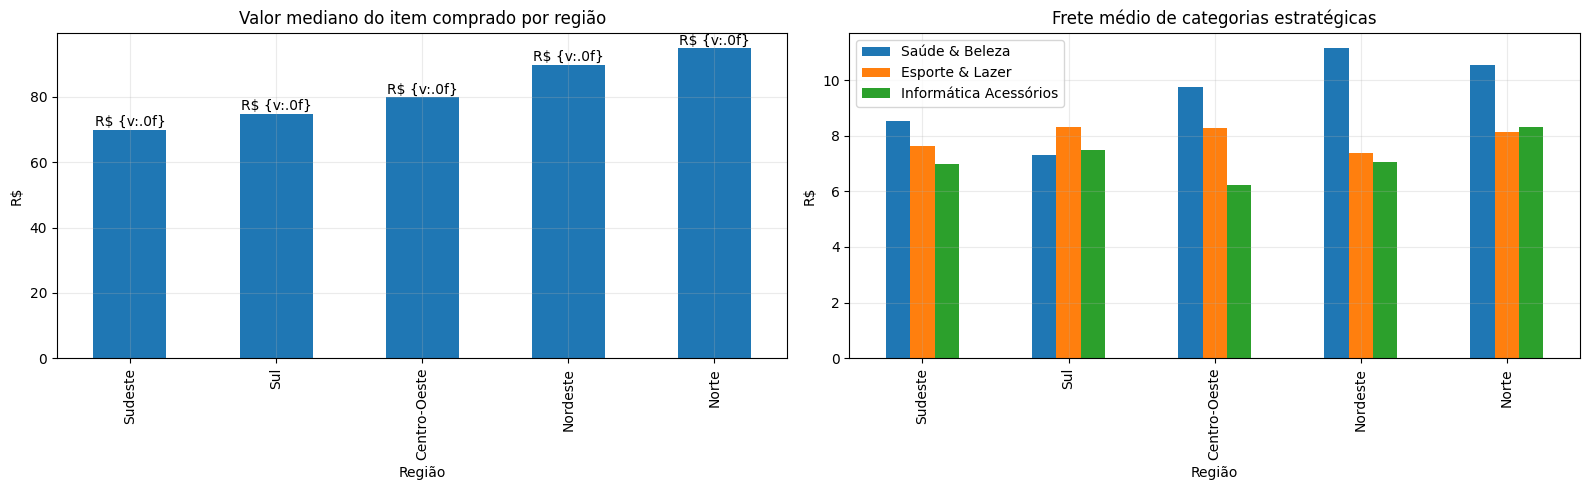

In [6]:
median_item_value = {
    'Sudeste': 69.99,
    'Sul': 74.90,
    'Centro-Oeste': 79.90,
    'Nordeste': 89.90,
    'Norte': 94.90,
}

category_freight = {
    'Saúde & Beleza': {'Centro-Oeste': 9.76, 'Nordeste': 11.14, 'Norte': 10.54, 'Sudeste': 8.54, 'Sul': 7.32},
    'Esporte & Lazer': {'Centro-Oeste': 8.28, 'Nordeste': 7.37, 'Norte': 8.12, 'Sudeste': 7.64, 'Sul': 8.31},
    'Informática Acessórios': {'Centro-Oeste': 6.21, 'Nordeste': 7.07, 'Norte': 8.32, 'Sudeste': 6.97, 'Sul': 7.50},
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

miv = pd.Series(median_item_value)
miv.plot(kind='bar', ax=axes[0])
axes[0].set_title('Valor mediano do item comprado por região')
axes[0].set_xlabel('Região')
axes[0].set_ylabel('R$')
for i, v in enumerate(miv.values):
    axes[0].text(i, v + 1.2, f"R$ {{v:.0f}}", ha='center')

cdf = pd.DataFrame(category_freight).loc[['Sudeste', 'Sul', 'Centro-Oeste', 'Nordeste', 'Norte']]
cdf.plot(kind='bar', ax=axes[1])
axes[1].set_title('Frete médio de categorias estratégicas')
axes[1].set_xlabel('Região')
axes[1].set_ylabel('R$')

plt.tight_layout()
plt.show()


### Leitura executiva
Esse bloco ajuda a explicar um comportamento simples e muito importante:

> **quando o frete sobe, produtos baratos perdem atratividade.**

Por isso, regiões mais penalizadas pela logística tendem a comprar itens de ticket maior.  
Na prática, isso afeta:
- mix de produto;
- performance de mídia;
- conversão;
- e estratégia comercial por região.


## 6. A demanda não pressiona a operação o tempo todo

**Base principal:** `notebooks/Davi/Analise_Sazonalidade.ipynb`

A sazonalidade mostra que o problema logístico piora justamente quando o volume acelera.  
Por isso, olhar apenas a média do ano esconde o que realmente estressa a operação.

Abaixo, mantivemos a leitura mensal do consolidado anterior e **simplificamos a leitura horária**:  
em vez do heatmap original, o segundo gráfico resume **em que faixas do dia o checkout concentra mais compras**.


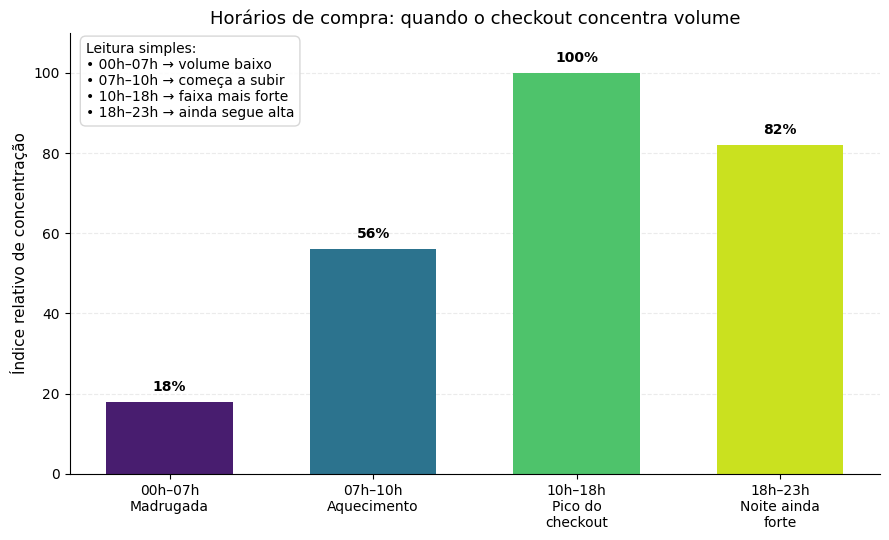

In [2]:
import matplotlib.pyplot as plt
from matplotlib import colormaps

faixas = [
    "00h–07h\nMadrugada",
    "07h–10h\nAquecimento",
    "10h–18h\nPico do\ncheckout",
    "18h–23h\nNoite ainda\nforte"
]

# Índice relativo de concentração
valores = [18, 56, 100, 82]

cmap = colormaps["viridis"]
cores = [cmap(x) for x in [0.08, 0.38, 0.72, 0.92]]

fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.bar(faixas, valores, color=cores, width=0.62)

ax.set_title("Horários de compra: quando o checkout concentra volume", fontsize=13)
ax.set_ylabel("Índice relativo de concentração", fontsize=11)
ax.set_ylim(0, 110)
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, valor in zip(bars, valores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        valor + 2,
        f"{valor}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.text(
    0.02, 0.98,
    "Leitura simples:\n"
    "• 00h–07h → volume baixo\n"
    "• 07h–10h → começa a subir\n"
    "• 10h–18h → faixa mais forte\n"
    "• 18h–23h → ainda segue alta",
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="lightgray", alpha=0.9)
)

plt.tight_layout()
plt.show()

### Leitura executiva
A ideia aqui não é complicar a análise temporal.  
É mostrar algo intuitivo: **existem momentos em que o sistema fica mais pressionado**.

Isso importa porque:
- estoque precisa estar preparado;
- transporte precisa ganhar folga;
- atendimento precisa se antecipar;
- e campanhas não podem ignorar a capacidade operacional.


## 7. Nem todo seller cresce com a mesma qualidade operacional

**Base principal:** `notebooks/Gustavo/vendedor_analise.ipynb`

O marketplace depende de sellers fortes, mas não basta vender muito.  
O ponto-chave é entender **quem sustenta receita sem degradar a experiência**.


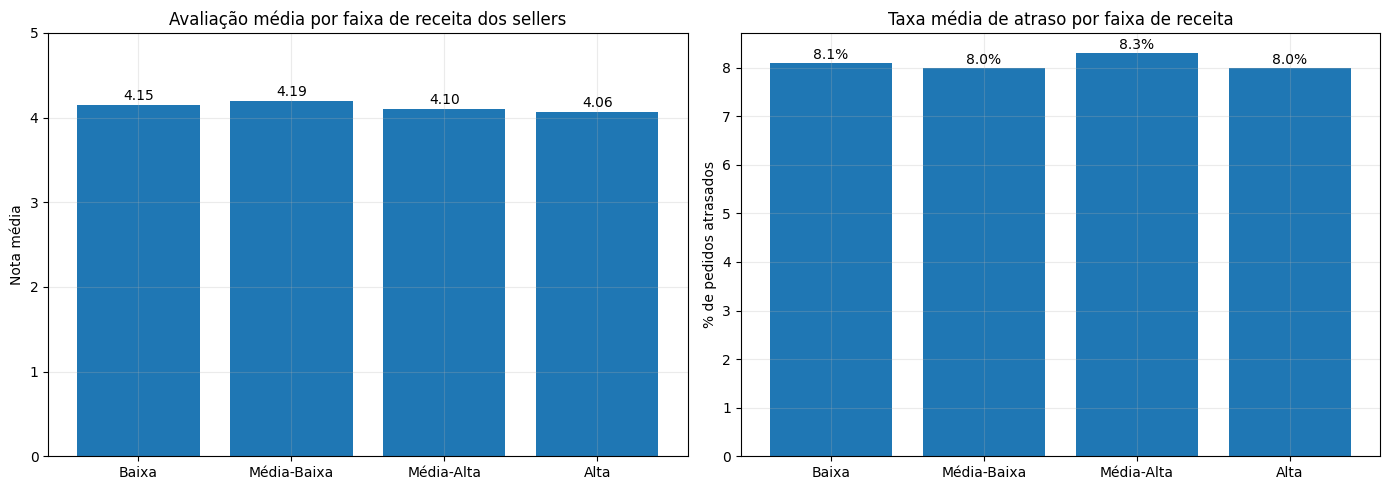

In [ ]:
revenue_bands = ['Baixa', 'Média-Baixa', 'Média-Alta', 'Alta']
seller_review_by_band = [4.15, 4.19, 4.10, 4.06]
seller_delay_by_band = [8.1, 8.0, 8.3, 8.0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(revenue_bands, seller_review_by_band)
axes[0].set_title('Avaliação média por faixa de receita dos sellers')
axes[0].set_ylabel('Nota média')
axes[0].set_ylim(0, 5)
for i, v in enumerate(seller_review_by_band):
    axes[0].text(i, v + 0.06, f"{v:.2f}", ha='center')

axes[1].bar(revenue_bands, seller_delay_by_band)
axes[1].set_title('Taxa média de atraso por faixa de receita')
axes[1].set_ylabel('% de pedidos atrasados')
for i, v in enumerate(seller_delay_by_band):
    axes[1].text(i, v + 0.08, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()


### Leitura executiva
Os sellers mais relevantes precisam ser acompanhados não só por receita, mas por qualidade de execução.

O resultado aqui é interessante:
- a avaliação média não despenca entre faixas de receita;
- mas o atraso continua sendo um ponto que merece vigilância constante.

Em resumo: **escala sem controle operacional pode corroer valor silenciosamente**.


## 8. Síntese executiva

Se tivermos que resumir todo o consolidado em poucas mensagens, elas seriam estas:

1. **O Brasil é desigual logisticamente**  
   A concentração no Sudeste ajuda a escala, mas penaliza regiões distantes.

2. **Atraso destrói satisfação**  
   O cliente percebe o prazo como parte do produto.

3. **Última milha pesa muito**  
   Capital e interior vivem realidades diferentes de custo e tempo.

4. **Frete muda o carrinho**  
   Em regiões mais caras, o cliente sobe o ticket e evita compras menos vantajosas.

5. **Sellers e categorias precisam ser lidos com qualidade, não só com volume**  
   Receita sozinha não conta a história inteira.


## 9. Como machine learning pode ajudar sem complicar a apresentação

A aplicação de ML faz mais sentido quando ligada a decisões práticas:

- **previsão de atraso:** priorizar pedidos com maior risco;
- **previsão de nota baixa:** agir antes que a experiência se deteriore;
- **segmentação de sellers e categorias:** identificar risco e potencial;
- **priorização logística por região:** usar dados para decidir onde reforçar malha e estoque.

A ideia não é “colocar IA em tudo”, mas usar modelos onde eles reduzem atrito, custo e incerteza.


## 10. Conclusão

A leitura conjunta dos notebooks aponta para uma conclusão simples:

> **o desafio central do e-commerce não é apenas vender mais, mas vender bem em um país com forte desigualdade logística.**

Quando região, última milha, categoria, seller e prazo se combinam de forma desfavorável:
- o frete sobe;
- a entrega demora;
- a nota cai;
- e o valor do negócio enfraquece.

Por isso, a melhor oportunidade não está apenas em crescer.  
Ela está em **crescer com mais previsibilidade, melhor operação e menos fricção para o cliente**.
